In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [63]:
df = pd.read_csv("../data/07-9_bike_ttareungi.csv")
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,202606,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621
1,202606,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
2,202606,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148
3,202606,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,202606,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220


#### 2. 데이터 정보 확인
- 행, 열 갯수
- 결측치
- 타입 체크

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   대여일자     5000 non-null   int64  
 1   대여소번호    5000 non-null   int64  
 2   대여소명     5000 non-null   str    
 3   대여구분코드   5000 non-null   str    
 4   성별       3188 non-null   str    
 5   연령대코드    5000 non-null   str    
 6   이용건수     5000 non-null   int64  
 7   운동량      4992 non-null   float64
 8   탄소량      4992 non-null   float64
 9   이동거리(M)  5000 non-null   float64
 10  이용시간(분)  5000 non-null   int64  
dtypes: float64(3), int64(4), str(4)
memory usage: 429.8 KB


#### 3. 전처리 시작

In [65]:
# df["월"] = df["대여일자"].astype(str).apply(lambda x : x[-2:]) # 먼저 숫자를 글자로 바꾸고, apply 적용할 수 있음
# df = df.drop("월", axis=1) # drop은 원본에 영향주지 않기 때문에 이렇게 할당해야 됨

df["대여일자"] = pd.to_datetime(df["대여일자"], format="%Y%m")
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148
3,2026-06-01,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,2026-06-01,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220


In [66]:
df["월"] = df["대여일자"].dt.month
df.head(3)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,6
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,6
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,6


In [67]:
df["월"].unique()   # 어떤 종류 있는지 볼 수 있다!

array([6], dtype=int32)

In [68]:
# 결측치 확인
df.isna().sum()

대여일자          0
대여소번호         0
대여소명          0
대여구분코드        0
성별         1812
연령대코드         0
이용건수          0
운동량           8
탄소량           8
이동거리(M)       0
이용시간(분)       0
월             0
dtype: int64

In [69]:
# 결측치 처리 - 운동량, 탄소량은 몇개 안되니 제거

df = df.dropna(subset=["운동량", "탄소량"]) # subset 통해 특정 결측치 있는 행만 지울 수 있음!
df.isna().sum()

대여일자          0
대여소번호         0
대여소명          0
대여구분코드        0
성별         1806
연령대코드         0
이용건수          0
운동량           0
탄소량           0
이동거리(M)       0
이용시간(분)       0
월             0
dtype: int64

In [70]:
df['성별'].unique() # 소문자도 있을 수 있으니 확인

<StringArray>
[nan, 'M', 'F']
Length: 3, dtype: str

In [71]:
df['성별'] = df['성별'].fillna("미상")
df.isna().sum()

대여일자       0
대여소번호      0
대여소명       0
대여구분코드     0
성별         0
연령대코드      0
이용건수       0
운동량        0
탄소량        0
이동거리(M)    0
이용시간(분)    0
월          0
dtype: int64

In [72]:
df['성별'].value_counts()   # 갯수 확인도 가능!

성별
미상    1806
M     1681
F     1505
Name: count, dtype: int64

In [73]:
df.head(3)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,미상,30대,123,8750.55,78.97,339960.75,2621,6
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,6
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,미상,40대,7,444.12,4.00,17254.05,148,6


In [74]:
# 건 당 운동량/탄소량/이동거리/이용시간 계산하기 -> 소수 두번째 자리까지

df['운동량/건별'] = round(df['운동량'] / df['이용건수'],2)
df['탄소량/건별'] = round(df['탄소량'] / df['이용건수'],2)
df['이동거리(M)/건별'] = round(df['이동거리(M)'] / df['이용건수'],2)
df['이용시간(분)/건별'] = round(df['이용시간(분)'] / df['이용건수'],2)
df.head(3)


,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,미상,30대,123,8750.55,78.97,339960.75,2621,6,71.14,0.64,2763.91,21.31
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,6,34.50,0.31,1340.52,11.53
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,미상,40대,7,444.12,4.00,17254.05,148,6,63.45,0.57,2464.86,21.14


In [75]:
df['연령대코드'].unique()

<StringArray>
['30대', '~10대', '40대', '50대', '20대', '60대', '기타', '70대이상']
Length: 8, dtype: str

In [76]:
(df['연령대코드']=='기타').sum()

np.int64(426)

In [77]:
# 데이터 탐색
# 1. 성별 간 이용시간 차이
# 2. 성별 간 이동거리 차이
# 3. 가장 많이 사용하는 대여소
# 4. 대여소별로 이용시간
# 5. 대여소별로 이동거리

In [78]:
#1
gender_data = df.groupby("성별")[['이동거리(M)/건별', '이용시간(분)/건별']].mean().reset_index()
gender_data

,성별,이동거리(M)/건별,이용시간(분)/건별
0,F,3395.072512,31.711701
1,M,3529.823575,29.988667
2,미상,3442.849385,29.637697


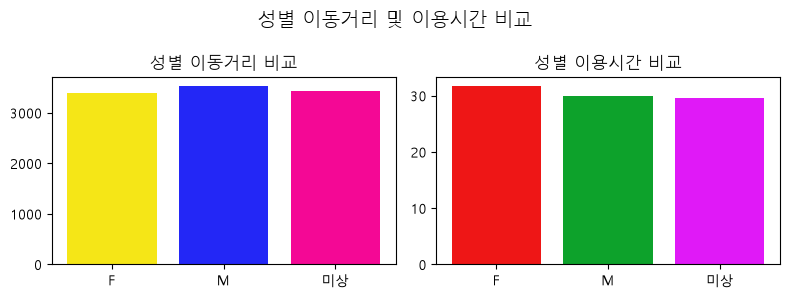

In [79]:
# 시각화
# 1행 2열 그래프

fig, axes = plt.subplots(1,2, figsize=(8,3))

# 첫 그래프 그리기 - axes[0]
axes[0].bar(gender_data['성별'],
            gender_data['이동거리(M)/건별'],
            color=["#F5E617", "#2327F6", "#F40895"])

axes[0].set_title("성별 이동거리 비교")

axes[1].bar(gender_data['성별'],
            gender_data['이용시간(분)/건별'],
            color=["#EE1616", "#0DA22B", "#E019F7"])

axes[1].set_title("성별 이용시간 비교")

# 전체 그래프 이름
plt.suptitle("성별 이동거리 및 이용시간 비교", fontsize=14)
# 그래프 사이 간격 자동 조절
plt.tight_layout()
plt.show()

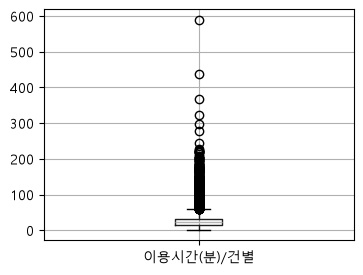

In [80]:
# 이상치 데이터 확인해보기 - 건별 이동거리, 이용시간
# DF에서 바로 plot도 가능!
plt.figure(figsize=(4,3))
df.boxplot(column='이용시간(분)/건별')
plt.show()

# df['이동거리(M)/건별']

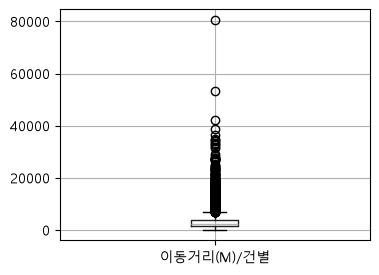

In [81]:
plt.figure(figsize=(4,3))
df.boxplot(column='이동거리(M)/건별')
plt.show()

In [82]:
# 이동거리 max 찾아보기

df[(df['이동거리(M)/건별'] == df['이동거리(M)/건별'].max())]

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
2104,2026-06-01,2094,2094.숭실대학교(중문),일일권(비회원 3시간),미상,기타,1,2072.5,18.68,80516.87,589,6,2072.5,18.68,80516.87,589.0


In [83]:
df[(df['이동거리(M)/건별'] >= 40000)].sort_values(by="이동거리(M)/건별", ascending=False)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
2104,2026-06-01,2094,2094.숭실대학교(중문),일일권(비회원 3시간),미상,기타,1,2072.50,18.68,80516.87,589,6,2072.50,18.68,80516.87,589.0
3919,2026-06-01,1858,"1858. 500번,507번 버스 종점 앞",일일권(3시간),M,20대,1,1375.75,12.40,53448.09,121,6,1375.75,12.40,53448.09,121.0
4257,2026-06-01,869,869.노들섬 동측 앞,일일권(3시간),M,~10대,1,1086.88,9.80,42225.38,178,6,1086.88,9.80,42225.38,178.0


In [84]:
len(df['대여소명'].unique())

2272

#### 월별 추이

In [85]:
df_1_6 = pd.read_csv("../data/서울특별시 공공자전거 이용정보(월별)_26.1-6.csv", encoding="cp949")
df_1_6.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,202601,102,102. 망원역 1번출구 앞,일일권,NaN,20대,7,313.42,2.76,11927.89,82
1,202601,102,102. 망원역 1번출구 앞,일일권,NaN,30대,15,680.77,6.57,28380.64,281
2,202601,102,102. 망원역 1번출구 앞,일일권,NaN,40대,5,281.56,2.60,11177.03,112
3,202601,102,102. 망원역 1번출구 앞,일일권,NaN,50대,1,46.27,0.36,1537.28,10
4,202601,102,102. 망원역 1번출구 앞,일일권,F,20대,40,2288.99,20.31,89410.71,806


In [97]:
# 총 이용건수 비교 (월별 추이 -> 선 그래프!)

df_1_6["대여일자"] = pd.to_datetime(df_1_6["대여일자"], format="%Y%m")
df_1_6["월"] = df_1_6["대여일자"].dt.month

monthly = df_1_6.groupby("월")["이용건수"].sum().reset_index()
monthly

,월,이용건수
0,1,1595817
1,2,1744693
2,3,2842284
3,4,3824308
4,5,3905121
5,6,4066671


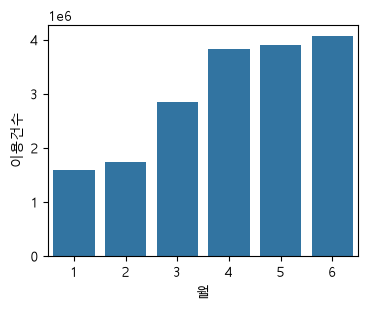

In [98]:
plt.figure(figsize=(4,3))
sns.barplot(data=monthly, x='월', y='이용건수')
plt.show()


In [100]:
df_1_6['대여구분코드'].value_counts()

대여구분코드
정기권             320872
일일권             247129
일일권(3시간)         35051
일일권(비회원)         31420
가족권              12095
가족권(2시간)          4903
일일권(비회원 3시간)      3651
가족권(3시간)           695
Name: count, dtype: int64

In [ ]:
# 1. 계절성 데이터 보려한다면 데이터 더 추가해서 concat
# 2. 한번 탈 때 거리 -> 대여권 종류와도 상관!(정기권, 일일권..)
# 남자와 여자에 따른 정기권 일일권 비교 (파이차트로도)
# 연령대로도 보기 등등...

In [ ]:
# 성별과 연령대 교차 분석

pivot = df.pivot_table(index="연령대코드",
                           columns="성별",
                           values="이용건수",
                           aggfunc="sum")

pivot

성별,F,M,미상
연령대코드,,,
20대,11887,16340,12093
30대,14537,22108,13791
40대,9443,16912,8467
50대,6307,14566,4986
60대,1807,4635,1325
70대이상,157,1143,273
~10대,3011,7758,184
기타,97,103,3405


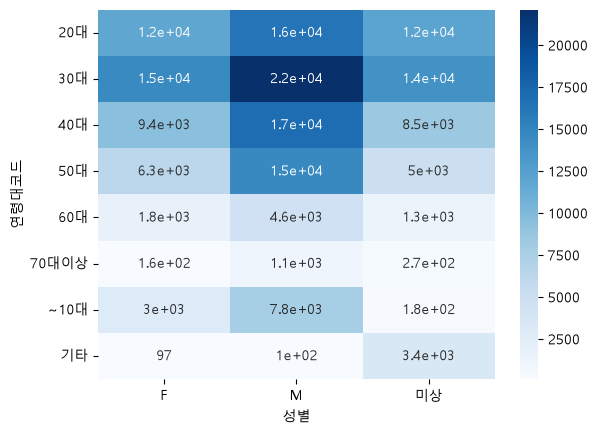

In [102]:
sns.heatmap(pivot,
            annot=True,
            cmap="Blues")

plt.show()